In [1]:
initial_parameters = {
    0.60: [0.05424044, 0.06461556, -0.09721599],
    0.70: [0.0821556, 0.03705277, -0.11171107],
    0.80: [0.07263012, 0.08563716, -0.03860591],
    0.90: [0.0735935, -0.06038758, -0.10268653]
}

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

service = QiskitRuntimeService(name="TJ")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))

qiskit_runtime_service.__init__:WARNING:2026-03-26 09:14:48,873: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-26 09:14:48,875: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_torino')>]


In [3]:
# backend = service.least_busy(operational=True, simulator=False)
backend = service.backend("ibm_fez")
print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-03-26 09:14:53,237: Using instance: open-instance, plan: open


Backend = ibm_fez


In [4]:
# We will start by using a local simulator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
noise_model = NoiseModel.from_backend(backend)
# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit.primitives import BackendEstimatorV2
sim_noise = AerSimulator(noise_model=noise_model)
sim_ideal = AerSimulator()
# generate a simulator that mimics the real quantum system
backend_sim_noise = sim_noise.from_backend(backend)
backend_sim_ideal = sim_ideal.from_backend(backend)
estimator_ideal = BackendEstimatorV2(backend=backend_sim_ideal)
estimator_noise = BackendEstimatorV2(backend=backend_sim_noise)


In [6]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.arange(0.30, 1.50, 0.05) 


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy


    #print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters[r]}")
    vqe_solver = VQE(estimator_noise, ansatz, COBYLA())
    vqe_solver.initial_point = initial_parameters[0.70]       # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, [H], [params])
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs[0]
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimator_noise),
        method="cobyla",
        options={"maxiter": 15, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.1269098883962054
The corresponding X is:
[ 0.0821556   0.03705277 -0.11171107]

Ground state energy for bond length 0.3 Å: -0.362986 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.0947666702190917
The corresponding X is:
[-0.06841437 -0.00868296 -0.06087103]

Ground state energy for bond length 0.35 Å: -0.582832 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.029439445680886
The corresponding X is:
[ 0.06421997  0.06856681 -0.01851677]

Ground state energy for bond length 0.39999999999999997 Å: -0.706496 Hartree
Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.985199566

In [13]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
print(df)

    Bond Length                                            Results  \
0          0.30  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
1          0.35  {'x': [0.11585993682825538, 0.0001201600330953...   
2          0.40  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
3          0.45  {'x': [0.09002597984269597, 0.0439822450891662...   
4          0.50  {'x': [0.11549750570116155, -0.000207360491114...   
5          0.55  {'x': [0.033579889953731325, -0.04829035605964...   
6          0.60  {'x': [0.025222257972730026, 0.004318705928873...   
7          0.65  {'x': [-0.03528443978052104, -0.08786912335648...   
8          0.70  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
9          0.75  {'x': [0.06094690279475859, -0.058352602161209...   
10         0.80  {'x': [0.03253596218970943, 0.0372033731580972...   
11         0.85  {'x': [0.1156273414603107, -9.07694599668954e-...   
12         0.90  {'x': [-0.015712921218211776, 0.05923414662417...   
13         0.95  {'x

In [14]:
# df.to_pickle("dataframe.pkl")
# df = pd.read_pickle("dataframe.pkl")

import pickle
location = "Data_results/Aer_Simulator_Results/Aer_Results_2.pkl"
df.to_pickle(location)

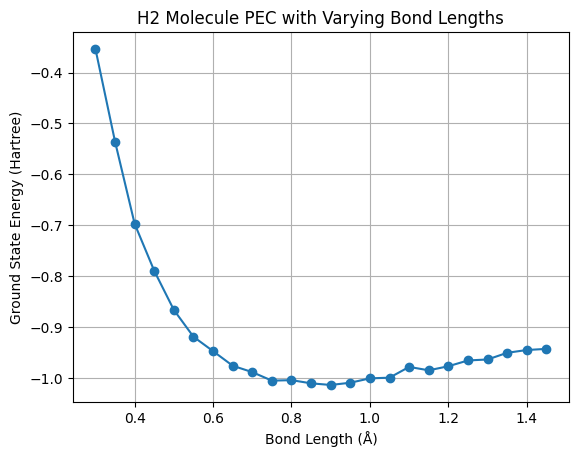

In [15]:
from matplotlib import pyplot as plt

plt.plot(bond_lengths, ground_energies, marker='o')
plt.grid(True)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H2 Molecule PEC with Varying Bond Lengths")
plt.show()

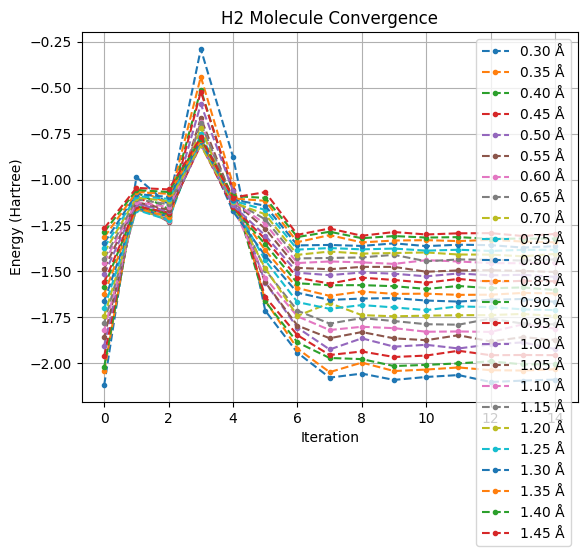

In [16]:
for history in energy_histories:
    plt.plot(history, marker='.', linestyle='--')
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Molecule Convergence")
plt.legend([f"{r:.2f} Å" for r in bond_lengths])
plt.show()

In [ ]:
print(f"ansatz depth = {ansatz_isa.decompose().depth()}")
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [11]:
df.head(7)

,Bond Length (Å),Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.413121,81.597544,1.763924,-2.177045,"[-2.1770454068621152, -1.0220554416210827, -1....","[0.0821556, 0.03705277, -0.11171107]"
1,0.45,"{'x': [-0.0033706870346540824, 0.0451681604390...",-0.839389,75.487845,1.175949,-2.015338,"[-2.0105942736722593, -1.1325272760607852, -1....","[-0.0033706870346540824, 0.045168160439022886,..."
2,0.60,"{'x': [0.11575914633884257, 2.8431066627275514...",-0.988101,71.791566,0.881962,-1.870063,"[-1.8607195786772115, -1.1598688180357695, -1....","[0.11575914633884257, 2.8431066627275514e-05, ..."
3,0.75,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-1.029875,69.016259,0.705570,-1.735445,"[-1.7354449074399125, -1.1717193782154336, -1....","[0.0821556, 0.03705277, -0.11171107]"
4,0.90,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-1.033038,73.185739,0.587975,-1.621012,"[-1.621012277530207, -1.161758090250079, -1.19...","[0.0821556, 0.03705277, -0.11171107]"
5,1.05,"{'x': [0.06107828723891725, -0.077151600565461...",-1.014423,68.484784,0.503978,-1.518401,"[-1.5106281806885804, -1.1313164249842411, -1....","[0.06107828723891725, -0.07715160056546114, -0..."
6,1.20,"{'x': [0.01809516726729382, 0.0142697567008296...",-0.990799,66.938597,0.440981,-1.431780,"[-1.4183306359694197, -1.1066713250367302, -1....","[0.01809516726729382, 0.014269756700829622, -0..."


In [ ]:
# # Saving Data
# import os
# import pickle
# import json
# from qiskit import qpy
# from google.colab import drive

# # Mount Google Drive (safe if already mounted)
# drive.mount('/content/drive')

# save_dir = "/content/drive/MyDrive/vqe_experiment"
# os.makedirs(save_dir, exist_ok=True)

# # -----------------------------
# # 1. Save optimizer result
# # -----------------------------
# with open(os.path.join(save_dir, "optimizer_result.pkl"), "wb") as f:
#     pickle.dump(result, f)

# # -----------------------------
# # 2. Save optimized parameters
# # -----------------------------
# optimal_parameters = result.x
# with open(os.path.join(save_dir, "optimal_parameters.pkl"), "wb") as f:
#     pickle.dump(optimal_parameters, f)

# # -----------------------------
# # 3. Save Hamiltonian
# # -----------------------------
# with open(os.path.join(save_dir, "hamiltonian.pkl"), "wb") as f:
#     pickle.dump(hamiltonian_isa, f)

# # -----------------------------
# # 4. Save Ansatz Circuit
# # -----------------------------
# with open(os.path.join(save_dir, "ansatz.qpy"), "wb") as f:
#     qpy.dump(ansatz_isa, f)

# # -----------------------------
# # 5. Save backend information
# # -----------------------------
# backend_info = {
#     "backend_name": backend.name,
#     "num_qubits": backend.num_qubits,
#     "version": backend.version,
# }

# with open(os.path.join(save_dir, "backend_info.json"), "w") as f:
#     json.dump(backend_info, f, indent=4)

# # -----------------------------
# # 6. Save experiment metadata
# # -----------------------------
# experiment_metadata = {
#     "bond_length": float(r),
#     "basis": "sto3g",
#     "shots": estimator.options.default_shots,
#     "optimizer": "COBYLA",
#     "maxiter": 40,
#     "energy": float(energy),
#     "ground_state_energy": float(ground_state_energy),
#     "nuclear_repulsion_energy": float(nuclear_repulsion),
#     "iterations": result.nfev,
#     "optimizer_success": result.success,
#     "backend": backend.name
# }

# with open(os.path.join(save_dir, "experiment_metadata.json"), "w") as f:
#     json.dump(experiment_metadata, f, indent=4)

# # -----------------------------
# # 7. Save DataFrame results
# # -----------------------------
# df.to_pickle(os.path.join(save_dir, "results_dataframe.pkl"))
# df.to_csv(os.path.join(save_dir, "results_dataframe.csv"), index=False)

# # -----------------------------
# # 8. Save additional circuit info
# # -----------------------------
# circuit_info = {
#     "num_qubits": ansatz_isa.num_qubits,
#     "num_parameters": ansatz_isa.num_parameters,
#     "circuit_depth": ansatz_isa.depth()
# }

# with open(os.path.join(save_dir, "circuit_info.json"), "w") as f:
#     json.dump(circuit_info, f, indent=4)

# print("✅ All VQE experiment data saved in:")
# print(save_dir)

# # Optional: list files saved
# print("\nSaved files:")
# print(os.listdir(save_dir))